In [1]:
import aopy
from aopy.data import db
from aopy.analysis import accllr
import os
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import h5py
import traceback
from scipy.stats import zscore
import datetime
from tqdm.auto import tqdm
from IPython.display import display, Markdown
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

from aopy.visualization import annotate_spatial_map_channels, place_Opto32_subplots
from aopy.data.bmi3d import tabulate_ts_data
from aopy.preproc.bmi3d import get_laser_trial_times
from aopy.preproc.quality import detect_bad_trials
from aopy.analysis.connectivity import get_acq_ch_near_stimulation_site
from aopy.analysis.connectivity import calc_connectivity_map_coh
from aopy.visualization import plot_angles, overlay_sulci_on_spatial_map
from aopy.analysis import calc_itpc, calc_fdrc_ranktest, calc_spatial_data_correlation
from aopy.analysis.latency import detect_itpc_response
from aopy.visualization import plot_annotated_stim_drive_data

data_dir = '/media/moor-data/raw'
preproc_dir = '/data/preprocessed'
postproc_dir = '/data/postprocessed/leo'
fig_dir = './figures'

version = 'v250623'


/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
sns.set_theme('paper', style='ticks', font_scale=1, font="Arial", rc={
    'svg.fonttype': 'none',
    "font.size" : 10,
    "axes.labelsize" : 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

In [3]:
from connectivity_analysis import *
from connectivity_plotting import *

## Cell counting

In [4]:
import statsmodels.api as sm
import numpy as np

# mCherry+ PV+
positive = 32
n = 834
confidence_level = 0.95

# Calculate confidence interval
ci_low, ci_upp = sm.stats.proportion_confint(positive, n, alpha=1-confidence_level, method='normal')

print(f"{positive}/{n} mCherry+ cells were PV+, 95% confidence interval: {100*ci_low:0.2f}% to {100*ci_upp:0.2f}%")


32/834 mCherry+ cells were PV+, 95% confidence interval: 2.53% to 5.14%


In [5]:
# mCherry+ VGlut+
positive = 274
n = 308
ci_low, ci_upp = sm.stats.proportion_confint(positive, n, alpha=1-confidence_level, method='normal')
print(f"{positive}/{n} mCherry+ cells were VGlut+, 95% confidence interval: {100*ci_low:0.2f}% to {100*ci_upp:0.2f}%")

274/308 mCherry+ cells were VGlut+, 95% confidence interval: 85.46% to 92.46%


## Fiber optic reliability

In [6]:
power_20mW_input = [3.9, 3.8, 4.2, 4.1, 3.6, 
                    4.8, 4.1, 3.3, 3.3, 2.5, 
                    4.2, 4.4, 3.5, 3.9, 4.3, 4.0, 
                    4.3, 4.2, 3.1, 3.9, 3.6, 3.8, 
                    4.2, 3.6, 3.6, 3.7, 3.4, 
                    3.5, 3.9, 4.0, 4.6, 3.9]

power_20mW_input2 = [3.9, 4.3, 4.4, 3.8, 3.9,
                     4.5, 3.9, 3.6, 3.7, 2.9,
                     4.2, 4.3, 4.0, 4.0, 4.4, 3.9,
                     4.3, 4.6, 3.9, 4.1, 3.8, 4.4,
                     4.5, 4.1, 3.8, 4.3, 3.5,
                     3.3, 4.1, 4.3, 3.1, 4.4]

power_20mW_input3 = [3.6, 4.1, 4.3, 4.0, 3.8,
                     4.5, 4.2, 3.6, 3.7, 2.8,
                     4.1, 4.3, 3.3, 3.6, 4.4, 4.1,
                     4.3, 4.5, 4.0, 4.1, 3.8, 4.8,
                     4.6, 4.0, 3.9, 4.3, 3.4,
                     3.2, 4.3, 4.2, 2.7, 4.3]

In [7]:
power_20mW_input = np.vstack((power_20mW_input, power_20mW_input2, power_20mW_input3))
len(power_20mW_input)

3

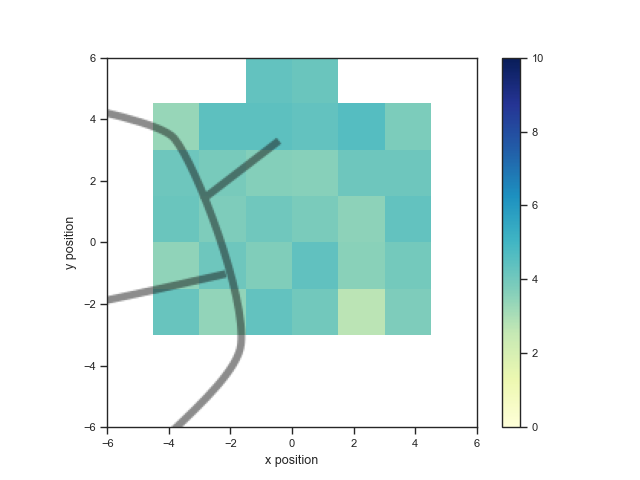

In [8]:
# Mean
im, pcm = plot_annotated_stim_drive_data(
    np.mean(power_20mW_input, axis=0), 
    'beignet', 'lm1', 0, cmap='YlGnBu'
)
im.set_clim(0,10)

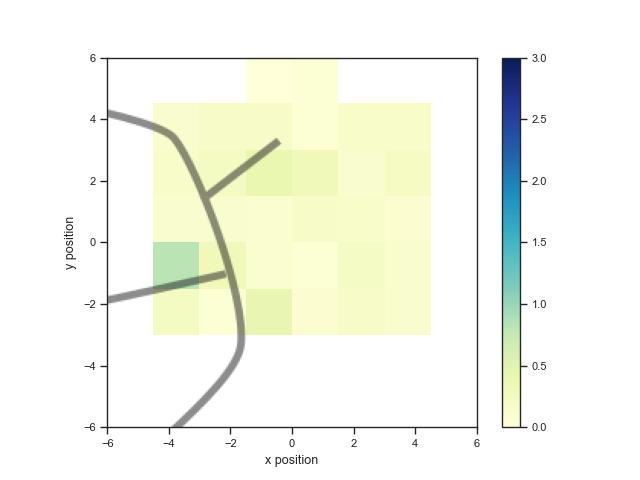

In [9]:
# Standard deviation
im, pcm = plot_annotated_stim_drive_data(
    np.std(power_20mW_input, axis=0), 
    'beignet', 'lm1', 0, cmap='YlGnBu'
)
im.set_clim(0,3)

In [10]:
# Stats
import statsmodels.api as sm

desc = sm.stats.DescrStatsW(np.mean(power_20mW_input, axis=0))
conf_int = desc.tconfint_mean(alpha=0.05)

print(f"95% confidence interval: ({conf_int[0]:.2f}, {conf_int[1]:.2f}) across space")

desc = sm.stats.DescrStatsW(np.mean(power_20mW_input, axis=1))
conf_int = desc.tconfint_mean(alpha=0.05)

print(f"95% confidence interval: ({conf_int[0]:.2f}, {conf_int[1]:.2f}) across repeated connections")

95% confidence interval: (3.80, 4.08) across space
95% confidence interval: (3.74, 4.14) across repeated connections
